In [386]:
def system(t, state):
    x, y, z = state
    dxdt = state[0]**2 + state[1]
    dydt = state[1] - state[0]
    dzdt = state[0]**3 - state[1]**3
    return [dxdt, dydt, dzdt]

In [387]:
from scipy.integrate import solve_ivp
import numpy as np

# Initial condition
x0 = np.array([.5, 0.05, 0.01])

# Time points (store solution at these times)
t_eval = np.linspace(0, 4, 4000)  # 200 snapshots

# Solve ODE
sol = solve_ivp(system, t_span=(0, 4), y0=x0, t_eval=t_eval, method='RK45')

# Extract solution
t = sol.t
snapshots = sol.y  # Shape: (3, 200)
snapshots.shape

(3, 4000)

In [388]:
X = np.array(sol.y)[:,:-1]
X_prime = np.array(sol.y)[:,1:]
X.shape, X_prime.shape

((3, 3999), (3, 3999))

In [389]:
# SVD on X
from scipy.linalg import svd
U, Sigma, Vt = svd(X, full_matrices=False)
Sigma, U.shape, Sigma.shape, Vt.shape

(array([3353.15604859,  108.78574812,   28.58240913]), (3, 3), (3,), (3, 3999))

In [390]:
np.allclose((U @ np.diag(Sigma) @ Vt), X)

True

In [391]:
r = 2

U_r = U[:, :r]
Sigma_r = Sigma[:r]
Vt_r = Vt[:r, :]

print(U_r.shape, Sigma_r.shape, Vt_r.shape)

(3, 2) (2,) (2, 3999)


In [392]:
A_tilde = U_r.T @ X_prime @ Vt_r.T @ np.linalg.inv(np.diag(Sigma_r))
A_tilde

array([[ 1.00180077e+00, -4.55569788e-04],
       [-7.17025566e-05,  1.00068399e+00]])

In [393]:
Lambda, W = np.linalg.eig(A_tilde)
Phi = U_r @ W
Phi, W # modes in orig space

(array([[ 0.00241601, -0.35880564],
        [ 0.00341991, -0.87876191],
        [ 0.99999123,  0.31469989]]),
 array([[ 0.99804599,  0.36960617],
        [-0.06248355,  0.92918851]]))

In [394]:
b, residuals, rank, s = np.linalg.lstsq(Phi, x0, rcond=None)
b.shape

(2,)

In [395]:
def dmd_predict(k, Phi, Lambda, b):
    x_pred = Phi @ (Lambda**k * b)
    return np.real(x_pred).flatten()  # Flatten to 1D!

In [396]:
print("x0:", x0.flatten())
print("x_pred_0:", dmd_predict(0, Phi, Lambda, b).flatten())
print("Phi @ b:", np.real(Phi @ b).flatten())

x0: [0.5  0.05 0.01]
x_pred_0: [0.08907438 0.21793414 0.01041848]
Phi @ b: [0.08907438 0.21793414 0.01041848]


In [397]:
print("U_r shape:", U_r.shape)
print("W shape:", W.shape)
print("Phi shape:", Phi.shape)
print("Phi dtype:", Phi.dtype)

U_r shape: (3, 2)
W shape: (2, 2)
Phi shape: (3, 2)
Phi dtype: float64


In [398]:
r = 3

U_r = U[:, :r]
Sigma_r = Sigma[:r]
Vt_r = Vt[:r, :]

# Recompute A_tilde, eigendecomp, Phi, b
A_tilde = U_r.T @ X_prime @ Vt_r.T @ np.linalg.inv(np.diag(Sigma_r))
Lambda, W = np.linalg.eig(A_tilde)
Phi = U_r @ W

x0 = sol.y[:, 0:1]
b, _, _, _ = np.linalg.lstsq(Phi, x0, rcond=None)
b = b.flatten()
residual = x0 - (Phi @ b)
print("Residual norm (r=3):", np.linalg.norm(residual))
Phi.shape, b.shape

Residual norm (r=3): 0.9425497334358542


((3, 3), (3,))

In [399]:
# Predict first 10 snapshots
k_values = np.arange(0, 10)
x_dmd_pred = np.array([dmd_predict(k, Phi, Lambda, b) for k in k_values]).T

# Compare with true snapshots
x_true = sol.y[:, :10]

print("DMD predictions (first 10 steps):")
print(x_dmd_pred)
print("\nTrue snapshots:")
print(x_true)
print("\nError:")
print(np.linalg.norm(x_dmd_pred - x_true, axis=0))

DMD predictions (first 10 steps):
[[0.5        0.49981421 0.49962824 0.49944209 0.49925576 0.49906925
  0.49888257 0.4986957  0.49850866 0.49832143]
 [0.05       0.04954981 0.04909936 0.04864864 0.04819766 0.04774641
  0.0472949  0.04684313 0.04639108 0.04593878]
 [0.01       0.01083201 0.01166535 0.01250002 0.01333602 0.01417336
  0.01501203 0.01585204 0.01669339 0.01753609]]

True snapshots:
[[0.5        0.5003     0.50059985 0.50089955 0.50119909 0.50149848
  0.50179772 0.50209681 0.50239574 0.50269451]
 [0.05       0.04954951 0.04909827 0.04864628 0.04819354 0.04774005
  0.0472858  0.04683079 0.04637504 0.04591852]
 [0.01       0.01012502 0.01025027 0.01037575 0.01050145 0.01062739
  0.01075355 0.01087995 0.01100657 0.01113342]]

Error:
[2.08462955e-16 8.57806281e-04 1.71653436e-03 2.57618612e-03
 3.43676342e-03 4.29826817e-03 5.16070223e-03 6.02406751e-03
 6.88836591e-03 7.75359932e-03]


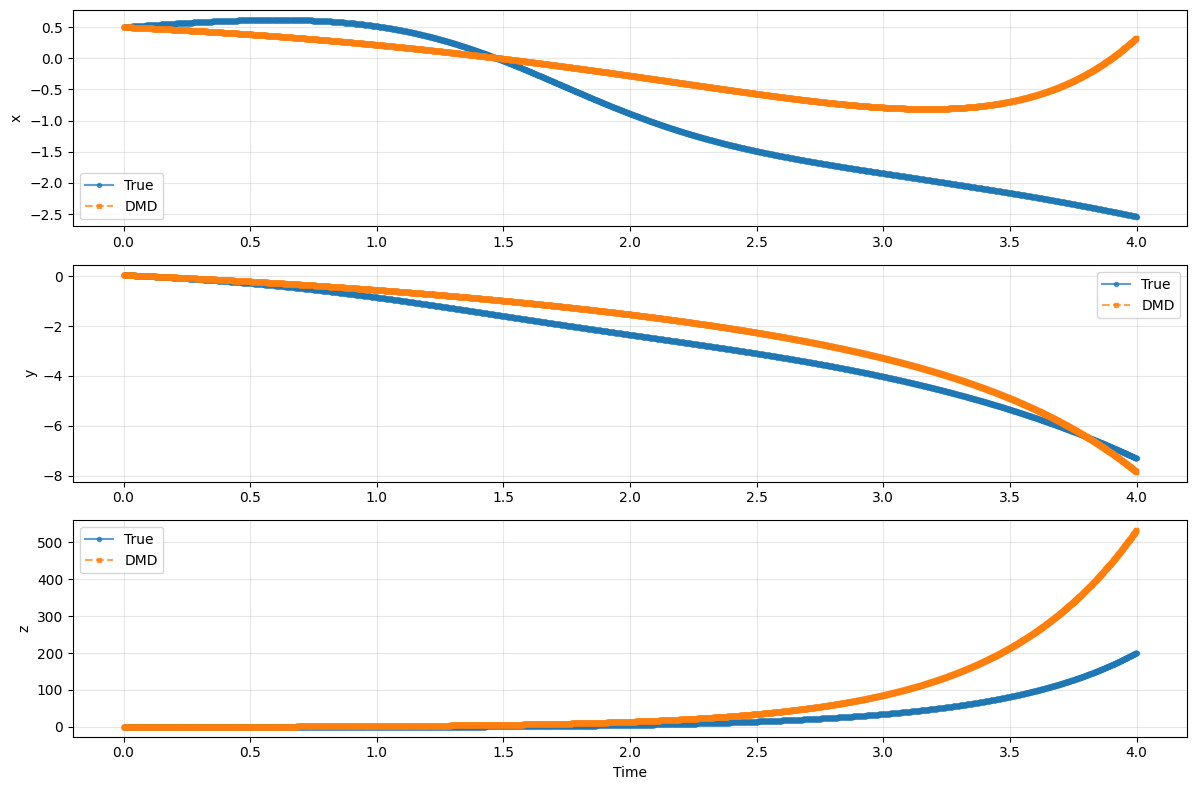

Error at step 10: 0.0086
Error at step 50: 0.0441
Error at step 100: 0.0907


In [400]:
import matplotlib.pyplot as plt
# Predict longer horizon
k_long = np.arange(0, 4000)
x_dmd_long = np.array([dmd_predict(k, Phi, Lambda, b) for k in k_long])
# Now x_dmd_long is (150, 3) — each row is a snapshot

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i in range(3):
    axes[i].plot(sol.t, sol.y[i], 'o-', label='True', markersize=3, alpha=0.7)
    axes[i].plot(k_long * 0.001, x_dmd_long[:, i], 's--', label='DMD', markersize=3, alpha=0.7)
    axes[i].set_ylabel(['x', 'y', 'z'][i])
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

# Error
errors = np.linalg.norm(x_dmd_long - sol.y.T, axis=1)
print(f"Error at step 10: {errors[10]:.4f}")
print(f"Error at step 50: {errors[50]:.4f}")
print(f"Error at step 100: {errors[100]:.4f}")

In [401]:
threshold = 0.1
steps_acceptable = np.where(errors > threshold)[0][0]
print(f"DMD breaks down after ~{steps_acceptable} steps (error > 0.1)")
print(f"Time horizon: {steps_acceptable * 0.001:.2f} seconds")

DMD breaks down after ~110 steps (error > 0.1)
Time horizon: 0.11 seconds
